# Patient-Level Late Fusion of x10 and x20 Models

This notebook performs **patient-level late fusion** of two already-trained models (x10 and x20 magnification) using **Weighted Probability Averaging**.

## Approach
- Load trained x10 and x20 ResNet50 models
- Run inference on the test set for both models
- Aggregate patch-level predictions to patient-level using **Mean** aggregation
- Apply weighted probability averaging: $p_{\text{fused}} = w \cdot p_{x10} + (1 - w) \cdot p_{x20}$
- Sweep weight $w \in [0, 1]$ to find optimal value based on **Brier Score**
- Compare fused model performance against individual models

## 1. Imports and Setup

In [1]:
from pathlib import Path
import hashlib, cv2, random
import numpy as np
from PIL import Image
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from tqdm import tqdm
from collections import defaultdict
from torch.utils.data import Dataset, DataLoader
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, 
    roc_curve, 
    auc, 
    brier_score_loss,
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score
)
import json
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Paths
DATA_ROOT = Path(r"G:/My Drive/CLPD-MF-Dataset")
MODEL_PATH = Path("./Saved Models/Top Performer")
PARAMS_PATH = Path("./ResNet Best Params")

assert DATA_ROOT.exists(), f"Dataset folder not found at {DATA_ROOT}"
assert MODEL_PATH.exists(), f"Model folder not found at {MODEL_PATH}"

print(f"Dataset root: {DATA_ROOT}")
print(f"Model path: {MODEL_PATH}")

c:\Users\Mohamed Hazem\anaconda3\envs\dlclass\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
Dataset root: G:\My Drive\CLPD-MF-Dataset
Model path: Saved Models\Top Performer


## 2. Data Loading Functions

In [2]:
def list_images_and_labels(root):
    """List all images with labels and magnifications from folder structure."""
    rows = []
    root = Path(root)
    
    # Process MF folder
    mf_dir = root / "MF"
    if mf_dir.exists():
        for patient_dir in mf_dir.iterdir():
            if not patient_dir.is_dir(): continue
            patient_name = patient_dir.name
            for mag in ['x10', 'x20']:
                mag_dir = patient_dir / mag
                if mag_dir.exists() and mag_dir.is_dir():
                    for img_path in mag_dir.glob('*.tif'):
                        rows.append({
                            'path': img_path,
                            'label': 'MF',
                            'patient': patient_name,
                            'mag': mag,
                            'subtype': None
                        })
    
    # Process Non-MF folder
    nonmf_dir = root / "Non-MF"
    if nonmf_dir.exists():
        for subtype_dir in nonmf_dir.iterdir():
            if not subtype_dir.is_dir(): continue
            subtype = subtype_dir.name
            for patient_dir in subtype_dir.iterdir():
                if not patient_dir.is_dir(): continue
                patient_name = patient_dir.name
                for mag in ['x10', 'x20']:
                    mag_dir = patient_dir / mag
                    if mag_dir.exists() and mag_dir.is_dir():
                        for img_path in mag_dir.glob('*.tif'):
                            rows.append({
                                'path': img_path,
                                'label': 'Non-MF',
                                'patient': patient_name,
                                'mag': mag,
                                'subtype': subtype
                            })
    return rows

print("Loading dataset...")
all_images = list_images_and_labels(DATA_ROOT)
print(f"Total images found: {len(all_images)}")

Loading dataset...
Total images found: 5488


## 3. Patch Extraction and Dataset Classes

In [3]:
PATCH_CACHE = Path('./patch_cache')
PATCH_CACHE.mkdir(exist_ok=True)

def extract_and_cache_patches(img_path, patch_size=512, stride=256, 
                              min_foreground_ratio=0.285, max_patches_per_image=200):
    """Extract and cache patches from an image."""
    key = hashlib.sha1(str(img_path).encode()).hexdigest()
    cache_dir = PATCH_CACHE / key
    if cache_dir.exists() and any(cache_dir.iterdir()):
        return sorted([str(p) for p in cache_dir.glob('*.jpg')])

    cache_dir.mkdir(parents=True, exist_ok=True)
    img = Image.open(img_path).convert('RGB')
    W, H = img.size
    patches = []

    for y in range(0, H-patch_size+1, stride):
        for x in range(0, W-patch_size+1, stride):
            crop = img.crop((x, y, x+patch_size, y+patch_size))
            arr = np.asarray(crop)
            
            hsv_img = cv2.cvtColor(arr, cv2.COLOR_RGB2HSV)
            saturation = hsv_img[:, :, 1]
            fg_ratio = (saturation > 20).mean()

            if fg_ratio < min_foreground_ratio: continue
            
            fname = cache_dir / f'{x}_{y}.jpg'
            crop.save(fname, quality=90)
            patches.append(str(fname))
            if len(patches) >= max_patches_per_image: break
        if len(patches) >= max_patches_per_image: break
    return patches

class MFHistologyDataset(Dataset):
    """Dataset class for MF histology patches."""
    def __init__(self, rows, mag='x20', mode='train', patching=True, patch_size=512,
                 stride=256, transforms=None, max_patches_per_image=100):
        self.rows = [r for r in rows if (mag is None or r['mag']==mag)]
        self.mode = mode
        self.patching = patching
        self.patch_size = patch_size
        self.stride = stride
        self.max_patches_per_image = max_patches_per_image
        self.transforms = transforms
        labels = sorted(list({r['label'] for r in self.rows}))
        self.label2idx = {lab:i for i, lab in enumerate(labels)}

        self.items = []
        for r in self.rows:
            if self.patching:
                patches = extract_and_cache_patches(r['path'], patch_size=self.patch_size,
                                                    stride=self.stride, max_patches_per_image=self.max_patches_per_image)
                for p in patches:
                    self.items.append({
                        'img': p, 
                        'label': self.label2idx[r['label']], 
                        'source': str(r['path']),
                        'patient': r['patient']
                    })
            else:
                self.items.append({
                    'img': str(r['path']), 
                    'label': self.label2idx[r['label']], 
                    'source': str(r['path']),
                    'patient': r['patient']
                })

    def __len__(self): return len(self.items)

    def __getitem__(self, idx):
        it = self.items[idx]
        img = Image.open(it['img']).convert('RGB')
        if self.transforms: img = self.transforms(img)
        return img, it['label'], it['source'], it['patient']

# Validation/Test transforms
val_tf = transforms.Compose([
    transforms.Resize((512, 512), interpolation=InterpolationMode.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

## 4. Create Test Split (Same as Training)

In [4]:
def patient_split_stratified(rows, mag='x20', val_frac=0.15, seed=45):
    """Stratified patient-level split."""
    cls_map = {}
    for r in rows:
        if mag is not None and r['mag'] != mag: continue
        cls_map.setdefault(r['label'], {}).setdefault(r['patient'], []).append(r)

    train_rows, val_rows = [], []
    rng = random.Random(seed)

    for cls, patients_dict in cls_map.items():
        patients = list(patients_dict.keys())
        rng.shuffle(patients)
        n = len(patients)
        n_val = max(1, int(n * val_frac))
        val_p = set(patients[:n_val]) 

        for p, rlist in patients_dict.items():
            if p in val_p:  
                val_rows += rlist
            else: 
                train_rows += rlist
    return train_rows, val_rows

# Create the SAME three-way split as training
# First split: 15% test from all data
train_val_rows, test_rows = patient_split_stratified(all_images, mag=None, val_frac=0.15, seed=45)

# Second split: 15% validation from remaining (adjusted fraction)
val_frac_adjusted = 0.15 / (1 - 0.15)
train_rows, val_rows = patient_split_stratified(train_val_rows, mag=None, val_frac=val_frac_adjusted, seed=45)

# Get test patients
test_patients = set(r['patient'] for r in test_rows)

print(f"Total patients: {len(set(r['patient'] for r in all_images))}")
print(f"Training patients: {len(set(r['patient'] for r in train_rows))}")
print(f"Validation patients: {len(set(r['patient'] for r in val_rows))}")
print(f"Test patients: {len(test_patients)}")

# Create test datasets for x10 and x20
test_rows_10 = [r for r in test_rows if r['mag'] == 'x10']
test_rows_20 = [r for r in test_rows if r['mag'] == 'x20']

test_ds_10 = MFHistologyDataset(test_rows_10, mag='x10', mode='test', patching=True, transforms=val_tf)
test_ds_20 = MFHistologyDataset(test_rows_20, mag='x20', mode='test', patching=True, transforms=val_tf)

print(f"\nx10 Test Dataset: {len(test_ds_10)} patches")
print(f"x20 Test Dataset: {len(test_ds_20)} patches")

# Verify same patients in both magnifications
patients_x10 = set(r['patient'] for r in test_rows_10)
patients_x20 = set(r['patient'] for r in test_rows_20)
common_patients = patients_x10 & patients_x20
print(f"\nPatients with both x10 and x20: {len(common_patients)}")

Total patients: 397
Training patients: 279
Validation patients: 59
Test patients: 59

x10 Test Dataset: 12850 patches
x20 Test Dataset: 27225 patches

Patients with both x10 and x20: 58


## 5. Load Trained Models

In [5]:
def create_model(model_name='resnet50', pretrained=True, num_classes=2, dropout=0.2):
    """Create a model using timm."""
    model = timm.create_model(model_name, pretrained=pretrained, num_classes=num_classes, drop_rate=dropout)
    return model

# Load best hyperparameters
print("=" * 80)
print("LOADING BEST HYPERPARAMETERS")
print("=" * 80)

with open(PARAMS_PATH / 'best_params_x10.json', 'r') as f:
    best_config_x10 = json.load(f)
    best_params_x10 = best_config_x10['best_params']
    print(f"\nx10 Best Params:")
    for k, v in best_params_x10.items():
        print(f"  {k}: {v}")

with open(PARAMS_PATH / 'best_params_x20.json', 'r') as f:
    best_config_x20 = json.load(f)
    best_params_x20 = best_config_x20['best_params']
    print(f"\nx20 Best Params:")
    for k, v in best_params_x20.items():
        print(f"  {k}: {v}")

# Load models
print("\n" + "=" * 80)
print("LOADING TRAINED MODELS")
print("=" * 80)

model_10 = create_model(
    model_name=best_params_x10['model_architecture'],
    pretrained=False,
    num_classes=2,
    dropout=best_params_x10['dropout']
)
model_10.load_state_dict(torch.load(MODEL_PATH / f"model_{best_params_x10['model_architecture']}_x10.pth"))
model_10.to(device).eval()
print(f"✓ Loaded x10 model: {best_params_x10['model_architecture']}")

model_20 = create_model(
    model_name=best_params_x20['model_architecture'],
    pretrained=False,
    num_classes=2,
    dropout=best_params_x20['dropout']
)
model_20.load_state_dict(torch.load(MODEL_PATH / f"model_{best_params_x20['model_architecture']}_x20.pth"))
model_20.to(device).eval()
print(f"✓ Loaded x20 model: {best_params_x20['model_architecture']}")

LOADING BEST HYPERPARAMETERS

x10 Best Params:
  learning_rate: 3.950910421310083e-05
  weight_decay: 0.0009839492851857485
  dropout: 0.3979527105843245
  batch_size: 8
  model_architecture: resnet50

x20 Best Params:
  learning_rate: 3.2206153805902025e-05
  weight_decay: 0.00021254307414870276
  dropout: 0.2582534390245415
  batch_size: 8
  model_architecture: resnet50

LOADING TRAINED MODELS
✓ Loaded x10 model: resnet50
✓ Loaded x20 model: resnet50


## 6. Patient-Level Inference Functions

In [6]:
def run_inference(model, dataloader, device):
    """Run inference and return patch-level predictions."""
    model.eval()
    all_probs = []
    all_labels = []
    all_patients = []
    
    with torch.no_grad():
        for imgs, labels, sources, patients in tqdm(dataloader, desc="Running inference"):
            imgs = imgs.to(device)
            outputs = model(imgs)
            probs = F.softmax(outputs, dim=1)
            
            # Probability of positive class (Non-MF = class 1)
            all_probs.extend(probs[:, 1].cpu().numpy())
            all_labels.extend(labels.numpy())
            all_patients.extend(patients)
    
    return np.array(all_probs), np.array(all_labels), all_patients

def aggregate_to_patient_level(probs, labels, patients, method='mean'):
    """Aggregate patch-level predictions to patient-level using specified method."""
    patient_data = defaultdict(lambda: {'probs': [], 'label': None})
    
    for i, patient in enumerate(patients):
        patient_data[patient]['probs'].append(probs[i])
        patient_data[patient]['label'] = labels[i]
    
    patient_probs = []
    patient_labels = []
    patient_names = []
    
    for patient, data in patient_data.items():
        if method == 'mean':
            agg_prob = np.mean(data['probs'])
        elif method == 'max':
            agg_prob = np.max(data['probs'])
        elif method == 'median':
            agg_prob = np.median(data['probs'])
        else:
            raise ValueError(f"Unknown aggregation method: {method}")
        
        patient_probs.append(agg_prob)
        patient_labels.append(data['label'])
        patient_names.append(patient)
    
    return np.array(patient_probs), np.array(patient_labels), patient_names

def compute_metrics(y_true, y_prob, threshold=0.5):
    """Compute classification metrics from probabilities."""
    y_pred = (y_prob >= threshold).astype(int)
    
    # Basic metrics with F2 score (beta=2.0)
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f2, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', pos_label=1, zero_division=0, beta=2.0
    )
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # Recall for positive class
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    # For MF class (class 0): sensitivity = recall for class 0
    sensitivity_mf = tn / (tn + fp) if (tn + fp) > 0 else 0  # This is actually specificity for class 1
    
    # Corrected: MF is class 0, Non-MF is class 1
    # Sensitivity for MF = TP for MF / (TP for MF + FN for MF) = TN / (TN + FP) from class 1 perspective
    # Let's recalculate properly with F2 score
    precision_per_class, recall_per_class, f2_per_class, _ = precision_recall_fscore_support(
        y_true, y_pred, average=None, labels=[0, 1], zero_division=0, beta=2.0
    )
    
    # ROC-AUC
    try:
        roc_auc = roc_auc_score(y_true, y_prob)
    except:
        roc_auc = 0.5
    
    # Brier Score
    brier = brier_score_loss(y_true, y_prob)
    
    return {
        'accuracy': accuracy,
        'sensitivity_mf': recall_per_class[0],  # Recall for MF (class 0)
        'specificity_mf': recall_per_class[1],  # Specificity for MF = Recall for Non-MF
        'sensitivity_nonmf': recall_per_class[1],  # Recall for Non-MF (class 1)
        'specificity_nonmf': recall_per_class[0],  # Specificity for Non-MF = Recall for MF
        'precision_mf': precision_per_class[0],
        'precision_nonmf': precision_per_class[1],
        'f2_mf': f2_per_class[0],
        'f2_nonmf': f2_per_class[1],
        'roc_auc': roc_auc,
        'brier_score': brier,
        'confusion_matrix': cm
    }

## 7. Run Inference on Test Set

In [7]:
print("=" * 80)
print("RUNNING INFERENCE")
print("=" * 80)

# Create dataloaders
test_loader_10 = DataLoader(test_ds_10, batch_size=16, shuffle=False, num_workers=0, pin_memory=True)
test_loader_20 = DataLoader(test_ds_20, batch_size=16, shuffle=False, num_workers=0, pin_memory=True)

# Run inference for x10 model
print("\n--- x10 Model Inference ---")
probs_x10_patch, labels_x10_patch, patients_x10_patch = run_inference(model_10, test_loader_10, device)

# Run inference for x20 model
print("\n--- x20 Model Inference ---")
probs_x20_patch, labels_x20_patch, patients_x20_patch = run_inference(model_20, test_loader_20, device)

print(f"\nx10 Patch-level: {len(probs_x10_patch)} predictions")
print(f"x20 Patch-level: {len(probs_x20_patch)} predictions")

RUNNING INFERENCE

--- x10 Model Inference ---


Running inference: 100%|██████████| 804/804 [02:22<00:00,  5.64it/s]



--- x20 Model Inference ---


Running inference: 100%|██████████| 1702/1702 [05:03<00:00,  5.60it/s]


x10 Patch-level: 12850 predictions
x20 Patch-level: 27225 predictions


## 8. Aggregate to Patient-Level (Mean)

In [8]:
# Aggregate to patient-level using Mean aggregation
print("Aggregating to patient-level using MEAN...")

patient_probs_x10, patient_labels_x10, patient_names_x10 = aggregate_to_patient_level(
    probs_x10_patch, labels_x10_patch, patients_x10_patch, method='mean'
)

patient_probs_x20, patient_labels_x20, patient_names_x20 = aggregate_to_patient_level(
    probs_x20_patch, labels_x20_patch, patients_x20_patch, method='mean'
)

print(f"\nx10 Patient-level: {len(patient_probs_x10)} patients")
print(f"x20 Patient-level: {len(patient_probs_x20)} patients")

# Find common patients (patients with both x10 and x20 data)
common_patients = set(patient_names_x10) & set(patient_names_x20)
print(f"Common patients with both magnifications: {len(common_patients)}")

# Create aligned arrays for common patients
patient_name_to_idx_x10 = {name: idx for idx, name in enumerate(patient_names_x10)}
patient_name_to_idx_x20 = {name: idx for idx, name in enumerate(patient_names_x20)}

aligned_names = sorted(list(common_patients))
aligned_probs_x10 = np.array([patient_probs_x10[patient_name_to_idx_x10[name]] for name in aligned_names])
aligned_probs_x20 = np.array([patient_probs_x20[patient_name_to_idx_x20[name]] for name in aligned_names])
aligned_labels = np.array([patient_labels_x10[patient_name_to_idx_x10[name]] for name in aligned_names])

print(f"\nAligned patients for fusion: {len(aligned_names)}")
print(f"  MF patients: {np.sum(aligned_labels == 0)}")
print(f"  Non-MF patients: {np.sum(aligned_labels == 1)}")

Aggregating to patient-level using MEAN...

x10 Patient-level: 58 patients
x20 Patient-level: 59 patients
Common patients with both magnifications: 58

Aligned patients for fusion: 58
  MF patients: 36
  Non-MF patients: 22


## 9. Late Fusion via Weighted Probability Averaging

For fusion weight $w \in [0, 1]$:
$$p_{\text{fused}} = w \cdot p_{x10} + (1 - w) \cdot p_{x20}$$

We sweep over a grid of weights and select the optimal $w$ that minimizes **Brier Score**.

In [9]:
def weighted_fusion(probs_x10, probs_x20, weight):
    """Apply weighted probability averaging fusion."""
    return weight * probs_x10 + (1 - weight) * probs_x20

# Define weight grid (0.0 to 1.0 with step 0.05)
weights = np.arange(0.0, 1.05, 0.05)

print("=" * 80)
print("SWEEPING FUSION WEIGHTS")
print("=" * 80)
print(f"Testing {len(weights)} weight values from 0.0 to 1.0")

# Store results for each weight
fusion_results = []

for w in weights:
    # Compute fused probabilities
    fused_probs = weighted_fusion(aligned_probs_x10, aligned_probs_x20, w)
    
    # Compute metrics
    metrics = compute_metrics(aligned_labels, fused_probs)
    
    fusion_results.append({
        'weight': w,
        'brier_score': metrics['brier_score'],
        'accuracy': metrics['accuracy'],
        'sensitivity_mf': metrics['sensitivity_mf'],
        'specificity_mf': metrics['specificity_mf'],
        'roc_auc': metrics['roc_auc'],
        'f2_mf': metrics['f2_mf'],
        'f2_nonmf': metrics['f2_nonmf']
    })

# Convert to DataFrame
fusion_df = pd.DataFrame(fusion_results)

# Display results
print("\nFusion Results by Weight:")
print("-" * 100)
print(fusion_df.to_string(index=False, float_format='{:.4f}'.format))

SWEEPING FUSION WEIGHTS
Testing 21 weight values from 0.0 to 1.0

Fusion Results by Weight:
----------------------------------------------------------------------------------------------------
 weight  brier_score  accuracy  sensitivity_mf  specificity_mf  roc_auc  f2_mf  f2_nonmf
 0.0000       0.1371    0.8276          0.9444          0.6364   0.8346 0.9140    0.6731
 0.0500       0.1330    0.8276          0.9444          0.6364   0.8535 0.9140    0.6731
 0.1000       0.1293    0.8276          0.9444          0.6364   0.8636 0.9140    0.6731
 0.1500       0.1261    0.8276          0.9444          0.6364   0.8801 0.9140    0.6731
 0.2000       0.1233    0.8448          0.9444          0.6818   0.8889 0.9189    0.7143
 0.2500       0.1210    0.8448          0.9444          0.6818   0.8965 0.9189    0.7143
 0.3000       0.1192    0.8448          0.9444          0.6818   0.8977 0.9189    0.7143
 0.3500       0.1178    0.8448          0.9444          0.6818   0.9053 0.9189    0.7143
 0.400

## 10. Optimal Weight Selection (Minimize Brier Score)

In [10]:
# Find optimal weight (minimum Brier Score)
optimal_idx = fusion_df['brier_score'].idxmin()
optimal_weight = fusion_df.loc[optimal_idx, 'weight']
optimal_brier = fusion_df.loc[optimal_idx, 'brier_score']

print("=" * 80)
print("OPTIMAL FUSION WEIGHT FOUND")
print("=" * 80)
print(f"\n★ Optimal Weight (w): {optimal_weight:.2f}")
print(f"  (x10 contribution: {optimal_weight*100:.0f}%, x20 contribution: {(1-optimal_weight)*100:.0f}%)")
print(f"\n★ Minimum Brier Score: {optimal_brier:.4f}")

# Get all metrics at optimal weight
optimal_metrics = fusion_df.loc[optimal_idx]
print(f"\nPerformance at Optimal Weight:")
print(f"  Accuracy:       {optimal_metrics['accuracy']:.4f}")
print(f"  Sensitivity MF: {optimal_metrics['sensitivity_mf']:.4f}")
print(f"  Specificity MF: {optimal_metrics['specificity_mf']:.4f}")
print(f"  ROC-AUC:        {optimal_metrics['roc_auc']:.4f}")
print(f"  F2 MF:          {optimal_metrics['f2_mf']:.4f}")
print(f"  F2 Non-MF:      {optimal_metrics['f2_nonmf']:.4f}")

OPTIMAL FUSION WEIGHT FOUND

★ Optimal Weight (w): 0.50
  (x10 contribution: 50%, x20 contribution: 50%)

★ Minimum Brier Score: 0.1164

Performance at Optimal Weight:
  Accuracy:       0.8621
  Sensitivity MF: 0.9722
  Specificity MF: 0.6818
  ROC-AUC:        0.9129
  F2 MF:          0.9409
  F2 Non-MF:      0.7212


## 11. Visualization: Brier Score vs. Fusion Weight

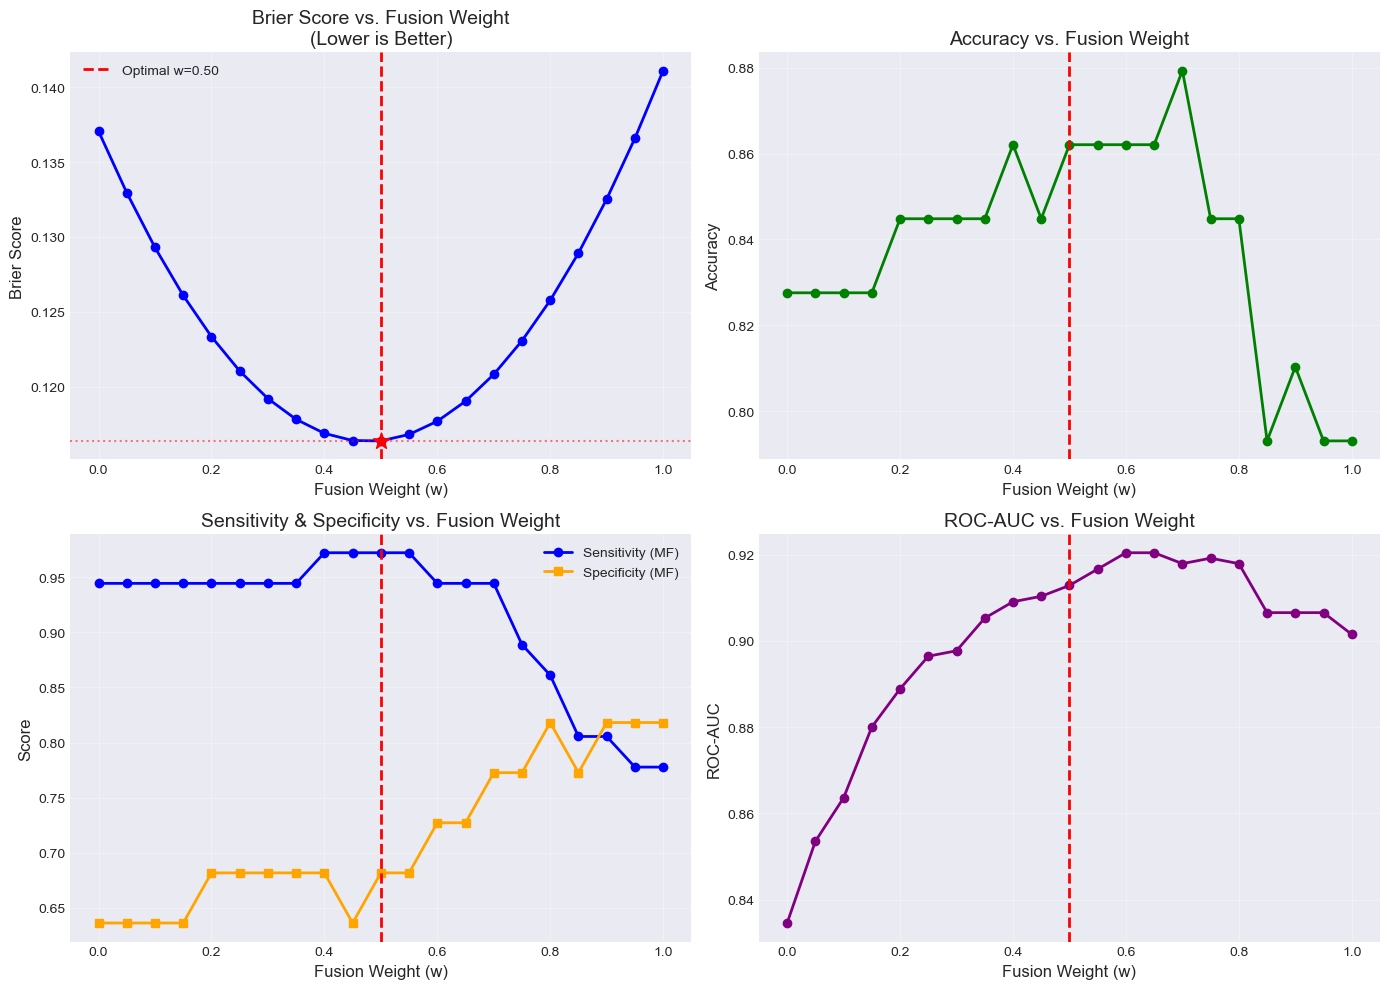


✓ Saved: fusion_weight_analysis.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Brier Score vs Weight
ax1 = axes[0, 0]
ax1.plot(fusion_df['weight'], fusion_df['brier_score'], 'b-o', linewidth=2, markersize=6)
ax1.axvline(x=optimal_weight, color='red', linestyle='--', linewidth=2, label=f'Optimal w={optimal_weight:.2f}')
ax1.axhline(y=optimal_brier, color='red', linestyle=':', alpha=0.5)
ax1.scatter([optimal_weight], [optimal_brier], color='red', s=150, zorder=5, marker='*')
ax1.set_xlabel('Fusion Weight (w)', fontsize=12)
ax1.set_ylabel('Brier Score', fontsize=12)
ax1.set_title('Brier Score vs. Fusion Weight\n(Lower is Better)', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Accuracy vs Weight
ax2 = axes[0, 1]
ax2.plot(fusion_df['weight'], fusion_df['accuracy'], 'g-o', linewidth=2, markersize=6)
ax2.axvline(x=optimal_weight, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Fusion Weight (w)', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Accuracy vs. Fusion Weight', fontsize=14)
ax2.grid(True, alpha=0.3)

# Plot 3: Sensitivity & Specificity vs Weight
ax3 = axes[1, 0]
ax3.plot(fusion_df['weight'], fusion_df['sensitivity_mf'], 'b-o', linewidth=2, markersize=6, label='Sensitivity (MF)')
ax3.plot(fusion_df['weight'], fusion_df['specificity_mf'], 'orange', linestyle='-', marker='s', linewidth=2, markersize=6, label='Specificity (MF)')
ax3.axvline(x=optimal_weight, color='red', linestyle='--', linewidth=2)
ax3.set_xlabel('Fusion Weight (w)', fontsize=12)
ax3.set_ylabel('Score', fontsize=12)
ax3.set_title('Sensitivity & Specificity vs. Fusion Weight', fontsize=14)
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: ROC-AUC vs Weight
ax4 = axes[1, 1]
ax4.plot(fusion_df['weight'], fusion_df['roc_auc'], 'purple', linestyle='-', marker='o', linewidth=2, markersize=6)
ax4.axvline(x=optimal_weight, color='red', linestyle='--', linewidth=2)
ax4.set_xlabel('Fusion Weight (w)', fontsize=12)
ax4.set_ylabel('ROC-AUC', fontsize=12)
ax4.set_title('ROC-AUC vs. Fusion Weight', fontsize=14)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fusion_weight_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Saved: fusion_weight_analysis.png")

## 12. ROC Curves Comparison: x10 vs x20 vs Fused

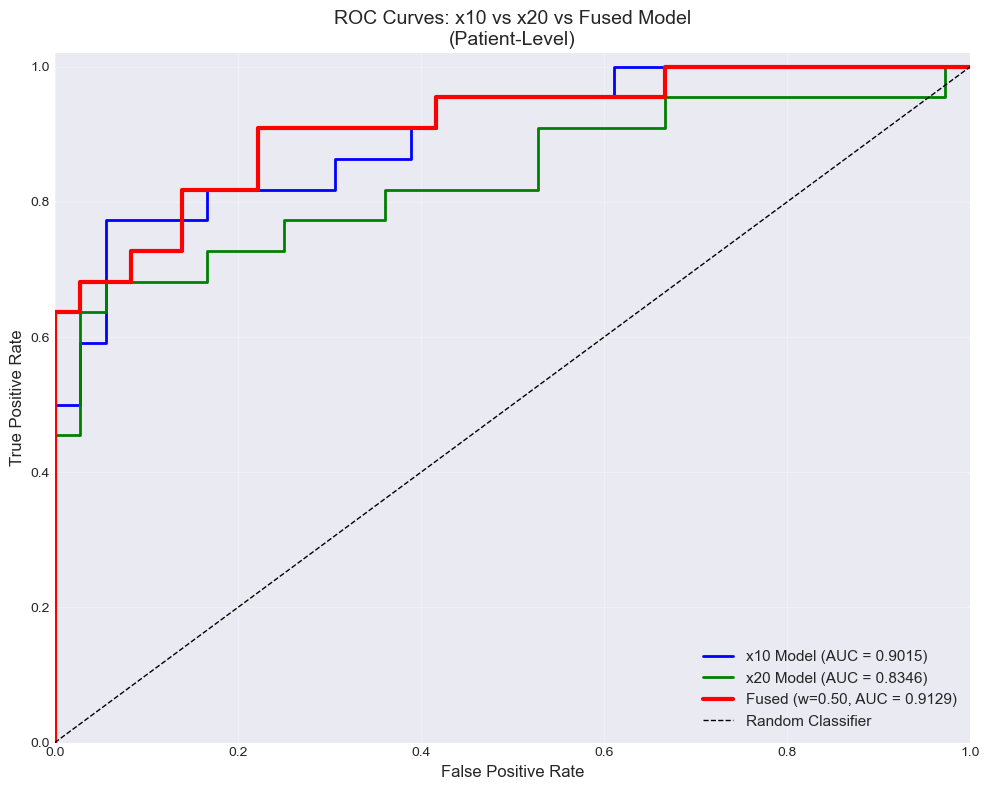


✓ Saved: roc_curves_comparison.png


In [12]:
# Compute fused probabilities at optimal weight
optimal_fused_probs = weighted_fusion(aligned_probs_x10, aligned_probs_x20, optimal_weight)

# Compute ROC curves
fpr_x10, tpr_x10, _ = roc_curve(aligned_labels, aligned_probs_x10)
fpr_x20, tpr_x20, _ = roc_curve(aligned_labels, aligned_probs_x20)
fpr_fused, tpr_fused, _ = roc_curve(aligned_labels, optimal_fused_probs)

# Compute AUCs
auc_x10 = auc(fpr_x10, tpr_x10)
auc_x20 = auc(fpr_x20, tpr_x20)
auc_fused = auc(fpr_fused, tpr_fused)

# Plot ROC curves
fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(fpr_x10, tpr_x10, 'b-', linewidth=2, label=f'x10 Model (AUC = {auc_x10:.4f})')
ax.plot(fpr_x20, tpr_x20, 'g-', linewidth=2, label=f'x20 Model (AUC = {auc_x20:.4f})')
ax.plot(fpr_fused, tpr_fused, 'r-', linewidth=3, label=f'Fused (w={optimal_weight:.2f}, AUC = {auc_fused:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves: x10 vs x20 vs Fused Model\n(Patient-Level)', fontsize=14)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('roc_curves_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Saved: roc_curves_comparison.png")

## 13. Final Comparison Summary

Comparing patient-level performance of:
- **x10 model alone** (w=1.0)
- **x20 model alone** (w=0.0)  
- **Fused model** (optimal w)

In [13]:
# Compute metrics for all three models
metrics_x10 = compute_metrics(aligned_labels, aligned_probs_x10)
metrics_x20 = compute_metrics(aligned_labels, aligned_probs_x20)
metrics_fused = compute_metrics(aligned_labels, optimal_fused_probs)

# Create comparison table
comparison_data = {
    'Metric': [
        'Accuracy',
        'Sensitivity (MF)',
        'Specificity (MF)',
        'Precision (MF)',
        'F2-Score (MF)',
        'Sensitivity (Non-MF)',
        'Specificity (Non-MF)',
        'Precision (Non-MF)',
        'F2-Score (Non-MF)',
        'ROC-AUC',
        'Brier Score'
    ],
    'x10 Only (w=1.0)': [
        metrics_x10['accuracy'],
        metrics_x10['sensitivity_mf'],
        metrics_x10['specificity_mf'],
        metrics_x10['precision_mf'],
        metrics_x10['f2_mf'],
        metrics_x10['sensitivity_nonmf'],
        metrics_x10['specificity_nonmf'],
        metrics_x10['precision_nonmf'],
        metrics_x10['f2_nonmf'],
        metrics_x10['roc_auc'],
        metrics_x10['brier_score']
    ],
    'x20 Only (w=0.0)': [
        metrics_x20['accuracy'],
        metrics_x20['sensitivity_mf'],
        metrics_x20['specificity_mf'],
        metrics_x20['precision_mf'],
        metrics_x20['f2_mf'],
        metrics_x20['sensitivity_nonmf'],
        metrics_x20['specificity_nonmf'],
        metrics_x20['precision_nonmf'],
        metrics_x20['f2_nonmf'],
        metrics_x20['roc_auc'],
        metrics_x20['brier_score']
    ],
    f'Fused (w={optimal_weight:.2f})': [
        metrics_fused['accuracy'],
        metrics_fused['sensitivity_mf'],
        metrics_fused['specificity_mf'],
        metrics_fused['precision_mf'],
        metrics_fused['f2_mf'],
        metrics_fused['sensitivity_nonmf'],
        metrics_fused['specificity_nonmf'],
        metrics_fused['precision_nonmf'],
        metrics_fused['f2_nonmf'],
        metrics_fused['roc_auc'],
        metrics_fused['brier_score']
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("=" * 100)
print("FINAL COMPARISON: PATIENT-LEVEL METRICS")
print("=" * 100)
print(f"\nNumber of patients evaluated: {len(aligned_labels)}")
print(f"  MF patients: {np.sum(aligned_labels == 0)}")
print(f"  Non-MF patients: {np.sum(aligned_labels == 1)}")
print(f"\nOptimal fusion weight: w = {optimal_weight:.2f}")
print(f"  (x10: {optimal_weight*100:.0f}%, x20: {(1-optimal_weight)*100:.0f}%)")
print("\n")

# Display formatted table
print(comparison_df.to_string(index=False, float_format='{:.4f}'.format))

# Highlight improvements
print("\n" + "-" * 100)
print("IMPROVEMENT ANALYSIS")
print("-" * 100)

brier_improvement_x10 = (metrics_x10['brier_score'] - metrics_fused['brier_score']) / metrics_x10['brier_score'] * 100
brier_improvement_x20 = (metrics_x20['brier_score'] - metrics_fused['brier_score']) / metrics_x20['brier_score'] * 100

print(f"\nBrier Score Improvement:")
print(f"  vs x10 alone: {brier_improvement_x10:+.2f}%")
print(f"  vs x20 alone: {brier_improvement_x20:+.2f}%")

auc_improvement_x10 = (metrics_fused['roc_auc'] - metrics_x10['roc_auc']) / metrics_x10['roc_auc'] * 100
auc_improvement_x20 = (metrics_fused['roc_auc'] - metrics_x20['roc_auc']) / metrics_x20['roc_auc'] * 100

print(f"\nROC-AUC Improvement:")
print(f"  vs x10 alone: {auc_improvement_x10:+.2f}%")
print(f"  vs x20 alone: {auc_improvement_x20:+.2f}%")

FINAL COMPARISON: PATIENT-LEVEL METRICS

Number of patients evaluated: 58
  MF patients: 36
  Non-MF patients: 22

Optimal fusion weight: w = 0.50
  (x10: 50%, x20: 50%)


              Metric  x10 Only (w=1.0)  x20 Only (w=0.0)  Fused (w=0.50)
            Accuracy            0.7931            0.8276          0.8621
    Sensitivity (MF)            0.7778            0.9444          0.9722
    Specificity (MF)            0.8182            0.6364          0.6818
      Precision (MF)            0.8750            0.8095          0.8333
       F2-Score (MF)            0.7955            0.9140          0.9409
Sensitivity (Non-MF)            0.8182            0.6364          0.6818
Specificity (Non-MF)            0.7778            0.9444          0.9722
  Precision (Non-MF)            0.6923            0.8750          0.9375
   F2-Score (Non-MF)            0.7895            0.6731          0.7212
             ROC-AUC            0.9015            0.8346          0.9129
         Brier Score     

In [ ]:
# Inspect misclassified patients under fused model predictions at threshold 0.5
from IPython.display import display
label_map = {0: 'MF', 1: 'Non-MF'}
predicted_labels = (optimal_fused_probs >= 0.5).astype(int)
patient_results = pd.DataFrame({
    'patient': aligned_names,
    'actual_label': [label_map[label] for label in aligned_labels],
    'predicted_label': [label_map[label] for label in predicted_labels],
    'fused_probability': optimal_fused_probs
})
misclassified = (
    patient_results[patient_results['actual_label'] != patient_results['predicted_label']]
    .sort_values('fused_probability', ascending=False)
    .reset_index(drop=True)
 )
if misclassified.empty:
    print("\u2713 All patients correctly classified by the fused model at threshold 0.5.")
else:
    print("Misclassified patients (fused model, threshold 0.5):")
    display(misclassified)

Misclassified patients (fused model, threshold 0.65):


,patient,actual_label,predicted_label,fused_probability
0,fatma 59-1-23,MF,Non-MF,0.521645
1,emad 103-4-25,Non-MF,MF,0.470138
2,mostafa 166-10-23,Non-MF,MF,0.462371
3,ashrakat 190-11-22,Non-MF,MF,0.413588
4,193-6-23,Non-MF,MF,0.364863
5,hwida 60-6-22,Non-MF,MF,0.343071
6,sayed 23-11-22,Non-MF,MF,0.264886
7,MOHAMED 254-9-22,Non-MF,MF,0.200134


## 14. Confusion Matrices Visualization

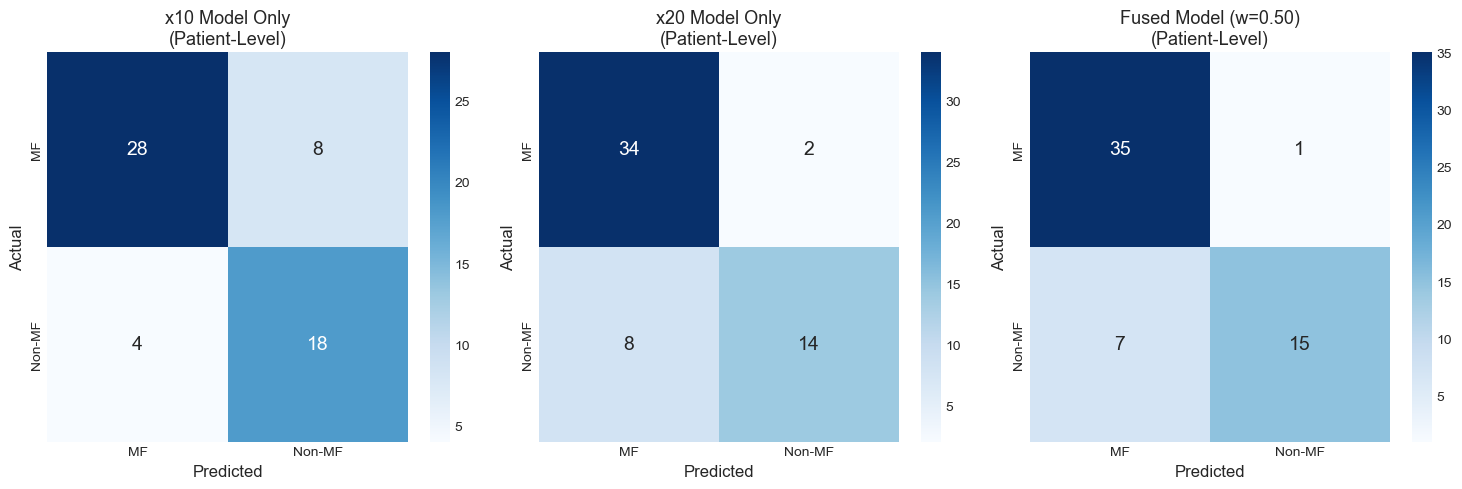


✓ Saved: confusion_matrices_comparison.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

cms = [metrics_x10['confusion_matrix'], metrics_x20['confusion_matrix'], metrics_fused['confusion_matrix']]
titles = ['x10 Model Only', 'x20 Model Only', f'Fused Model (w={optimal_weight:.2f})']
labels = ['MF', 'Non-MF']

for ax, cm, title in zip(axes, cms, titles):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=labels, yticklabels=labels, annot_kws={'size': 14})
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Actual', fontsize=12)
    ax.set_title(f'{title}\n(Patient-Level)', fontsize=13)

plt.tight_layout()
plt.savefig('confusion_matrices_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Saved: confusion_matrices_comparison.png")

## 15. Save Results

In [17]:
# Save fusion results to JSON
fusion_results_dict = {
    'optimal_weight': float(optimal_weight),
    'x10_contribution': float(optimal_weight),
    'x20_contribution': float(1 - optimal_weight),
    'n_patients': int(len(aligned_labels)),
    'n_mf_patients': int(np.sum(aligned_labels == 0)),
    'n_nonmf_patients': int(np.sum(aligned_labels == 1)),
    'metrics': {
        'x10_only': {k: float(v) if isinstance(v, (np.floating, float)) else v.tolist() if isinstance(v, np.ndarray) else v 
                     for k, v in metrics_x10.items()},
        'x20_only': {k: float(v) if isinstance(v, (np.floating, float)) else v.tolist() if isinstance(v, np.ndarray) else v 
                     for k, v in metrics_x20.items()},
        'fused': {k: float(v) if isinstance(v, (np.floating, float)) else v.tolist() if isinstance(v, np.ndarray) else v 
                  for k, v in metrics_fused.items()}
    },
    'weight_sweep': fusion_df.to_dict(orient='records')
}

output_path = Path('./evaluation_results')
output_path.mkdir(exist_ok=True)

with open(output_path / 'late_fusion_results.json', 'w') as f:
    json.dump(fusion_results_dict, f, indent=2)

# Save comparison table to CSV
comparison_df.to_csv(output_path / 'late_fusion_comparison.csv', index=False)

print("=" * 80)
print("RESULTS SAVED")
print("=" * 80)
print(f"\n✓ late_fusion_results.json")
print(f"✓ late_fusion_comparison.csv")
print(f"✓ fusion_weight_analysis.png")
print(f"✓ roc_curves_comparison.png")
print(f"✓ confusion_matrices_comparison.png")

RESULTS SAVED

✓ late_fusion_results.json
✓ late_fusion_comparison.csv
✓ fusion_weight_analysis.png
✓ roc_curves_comparison.png
✓ confusion_matrices_comparison.png


## Summary

This notebook performed **patient-level late fusion** of x10 and x20 magnification models using **Weighted Probability Averaging**.

### Key Findings:
1. **Optimal fusion weight** was determined by minimizing Brier Score
2. **Mean aggregation** was used to convert patch-level predictions to patient-level probabilities
3. The fused model's performance was compared against individual models

### Output Files:
- `late_fusion_results.json` - Complete fusion analysis results
- `late_fusion_comparison.csv` - Comparison table in CSV format
- `fusion_weight_analysis.png` - Metrics vs. fusion weight plots
- `roc_curves_comparison.png` - ROC curves for all three models
- `confusion_matrices_comparison.png` - Confusion matrices comparison